# Phase 4: Clustering Analysis (MiniBatchKMeans - Fast) Analysis

**Course**: Data Science and AI - Sharif University  
**Team**: Bahman Farhadian, Mahdi Samadi Azar  
**Dataset**: Divar Real Estate Advertisements (1M records)

---

## Objective

Segment the real estate market into distinct, interpretable categories that provide business value beyond simple statistics.

> **Instructor's guidance**: "If you're using features with vastly different scales in mean or variance, this greatly affects clustering. You must normalize if needed."

> "Do dimensionality reduction with PCA first, then cluster on principal components, then interpret again. See what differences you find."

> "If you use t-SNE, be aware it has stochastic behavior. Each run gives slightly different results. Only make claims about robust patterns that don't change between runs."

## What This Notebook Covers

1. **Data Loading & Feature Selection** - Select relevant features for clustering
2. **Preprocessing** - Handle missing values, outliers, normalization
3. **Optimal K Selection** - Elbow and Silhouette methods
4. **Approach 1: Cluster Original Features** - K-Means with PCA visualization
5. **Approach 2: Cluster PCA Components** - Compare with Approach 1
6. **t-SNE Visualization** - Multiple runs to verify robust patterns
7. **Cluster Interpretation** - Assign business-meaningful names
8. **Results & Export** - Save cluster assignments and profiles

---

## 1. Setup and Library Imports

In [1]:
import os
# Enable all CPU cores for parallel computation (KMeans uses OpenMP internally)
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count())
os.environ['OPENBLAS_NUM_THREADS'] = str(os.cpu_count())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Clustering and preprocessing
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plot styling (consistent with previous phases)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
sns.set_style('whitegrid')

# Color palette
COLORS = {
    'primary': '#2ecc71',
    'secondary': '#3498db',
    'accent': '#e74c3c',
    'neutral': '#95a5a6',
    'purple': '#9b59b6',
    'orange': '#e67e22',
    'teal': '#1abc9c'
}

# Cluster colors (for consistent visualization) - extended to support up to 10 clusters
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#e67e22', 
                  '#1abc9c', '#f39c12', '#34495e', '#e91e63', '#00bcd4']

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Project Structure and Data Loading

In [2]:
# Define project paths
import os

# Handle both notebook and nbconvert execution
if 'NOTEBOOK_PATH' in os.environ:
    PROJECT_ROOT = Path(os.environ['NOTEBOOK_PATH']).parent.parent
else:
    # Try to find project root
    cwd = Path.cwd()
    if cwd.name == 'notebooks':
        PROJECT_ROOT = cwd.parent
    elif (cwd / 'notebooks').exists():
        PROJECT_ROOT = cwd
    else:
        PROJECT_ROOT = cwd.parent

DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_PATH = PROJECT_ROOT / 'notebooks' / 'outputs' / 'figures'
MODELS_PATH = PROJECT_ROOT / 'notebooks' / 'outputs' / 'models'

# Create directories
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures path: {FIGURES_PATH}")
print(f"Figures path exists: {FIGURES_PATH.exists()}")

Project root: /root/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar
Figures path: /root/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/notebooks/outputs/figures
Figures path exists: True


In [3]:
# Load the enhanced dataset from Phase 2
DATA_FILE = DATA_PROCESSED / 'cleaned_data_with_features.csv'

print(f"Loading data from: {DATA_FILE}")
df_full = pd.read_csv(DATA_FILE, low_memory=False)
print(f"Full dataset: {len(df_full):,} rows")

# Filter to sale listings only (clustering for sale market)
df = df_full[df_full['listing_type'] == 'sell'].copy()
print(f"Sale listings: {len(df):,} rows")

Loading data from: /root/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/data/processed/cleaned_data_with_features.csv


Full dataset: 1,000,000 rows


Sale listings: 597,569 rows


## 3. Feature Selection and Engineering

We select features that are meaningful for market segmentation:
- **Price per sqm**: Core value metric
- **Building size**: Property size
- **Room count**: Property configuration
- **Amenities**: Elevator, parking, storage
- **City**: Location factor (target encoded by median price)

In [4]:
# Ensure numeric types
df['price_value'] = pd.to_numeric(df['price_value'], errors='coerce')
df['building_size'] = pd.to_numeric(df['building_size'], errors='coerce')
df['price_per_sqm'] = pd.to_numeric(df['price_per_sqm'], errors='coerce')

# Convert rooms_count to numeric
room_mapping = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5
}
df['rooms_numeric'] = df['rooms_count'].map(room_mapping)

# Convert amenities to binary (handle various formats)
for col in ['has_elevator', 'has_parking', 'has_warehouse']:
    if col in df.columns:
        # Convert to string first, then check for True/true/1
        df[col + '_binary'] = df[col].astype(str).str.lower().isin(['true', '1', '1.0']).astype(int)

print("Feature engineering complete")
print(f"\nFeature availability:")
print(f"  price_per_sqm: {df['price_per_sqm'].notna().sum():,} valid ({df['price_per_sqm'].notna().mean()*100:.1f}%)")
print(f"  building_size: {df['building_size'].notna().sum():,} valid ({df['building_size'].notna().mean()*100:.1f}%)")
print(f"  rooms_numeric: {df['rooms_numeric'].notna().sum():,} valid ({df['rooms_numeric'].notna().mean()*100:.1f}%)")

Feature engineering complete

Feature availability:
  price_per_sqm: 565,157 valid (94.6%)
  building_size: 597,508 valid (100.0%)
  rooms_numeric: 463,387 valid (77.5%)


### 3.1 City Target Encoding

We encode city by its median price per sqm. This creates a single numeric feature that captures the "price level" of each location.

In [5]:
# Calculate median price per sqm for each city
city_price_median = df.groupby('city_slug')['price_per_sqm'].median()

# Target encode: replace city name with its median price
df['city_price_level'] = df['city_slug'].map(city_price_median)

# Show encoding for top cities
print("City Target Encoding (by median price/sqm):")
print("=" * 50)
top_cities = city_price_median.sort_values(ascending=False).head(10)
for city, price in top_cities.items():
    if pd.notna(price):
        city_name = city.replace('-', ' ').title()
        print(f"{city_name:<25} -> {price/1e6:.1f}M Tomans/sqm")

print(f"\nCity price level: {df['city_price_level'].notna().sum():,} valid")

City Target Encoding (by median price/sqm):
Kish                      -> 100.0M Tomans/sqm
Tehran                    -> 85.7M Tomans/sqm
Fasham City               -> 61.3M Tomans/sqm
Lavasan City              -> 60.0M Tomans/sqm
Shemshak                  -> 53.8M Tomans/sqm
Salman Shahr              -> 50.0M Tomans/sqm
Garmdareh                 -> 43.4M Tomans/sqm
Shiraz                    -> 37.0M Tomans/sqm
Lahijan                   -> 35.2M Tomans/sqm
Isfahan                   -> 35.0M Tomans/sqm

City price level: 597,567 valid


## 4. Data Preprocessing

Following instructor guidance: normalize features with different scales.

### 4.1 Select Features and Handle Missing Values

In [6]:
# Define clustering features (only features with good availability)
clustering_features = [
    'price_per_sqm',
    'building_size',
    'rooms_numeric',
    'has_elevator_binary',
    'has_parking_binary',
    'has_warehouse_binary',
    'city_price_level'
]

# Check availability
print("Feature Availability:")
print("=" * 50)
for feat in clustering_features:
    if feat in df.columns:
        valid = df[feat].notna().sum()
        pct = valid / len(df) * 100
        print(f"{feat:<25} {valid:>10,} ({pct:>5.1f}%)")
    else:
        print(f"{feat:<25} MISSING COLUMN")

Feature Availability:
price_per_sqm                565,157 ( 94.6%)
building_size                597,508 (100.0%)
rooms_numeric                463,387 ( 77.5%)
has_elevator_binary          597,569 (100.0%)
has_parking_binary           597,569 (100.0%)
has_warehouse_binary         597,569 (100.0%)
city_price_level             597,567 (100.0%)


In [7]:
# Create clustering dataset
# Start with essential features that have high availability
essential_features = ['price_per_sqm', 'building_size', 'city_price_level']

# Filter: must have essential features
df_cluster = df[df['price_per_sqm'].notna() & df['building_size'].notna()].copy()
print(f"After requiring price_per_sqm and building_size: {len(df_cluster):,} rows")

# Apply reasonable bounds (same as Phase 3)
df_cluster = df_cluster[
    (df_cluster['price_per_sqm'] >= 5_000_000) &
    (df_cluster['price_per_sqm'] <= 500_000_000) &
    (df_cluster['building_size'] >= 20) &
    (df_cluster['building_size'] <= 1000)
].copy()
print(f"After outlier removal: {len(df_cluster):,} rows")

# Impute missing values for other features with median
df_cluster['rooms_numeric'] = df_cluster['rooms_numeric'].fillna(df_cluster['rooms_numeric'].median())
df_cluster['city_price_level'] = df_cluster['city_price_level'].fillna(df_cluster['city_price_level'].median())

# Binary features: fill missing with 0 (assume no amenity if not specified)
for col in ['has_elevator_binary', 'has_parking_binary', 'has_warehouse_binary']:
    if col in df_cluster.columns:
        df_cluster[col] = df_cluster[col].fillna(0).astype(int)

print(f"\nFinal clustering dataset: {len(df_cluster):,} rows")

After requiring price_per_sqm and building_size: 565,157 rows


After outlier removal: 468,402 rows

Final clustering dataset: 468,402 rows


### 4.2 Log Transformation for Skewed Variables

In [8]:
# Check skewness before transformation
print("Skewness before log transformation:")
print(f"  price_per_sqm: {df_cluster['price_per_sqm'].skew():.2f}")
print(f"  building_size: {df_cluster['building_size'].skew():.2f}")
print(f"  city_price_level: {df_cluster['city_price_level'].skew():.2f}")

# Apply log transformation to highly skewed variables
df_cluster['log_price_per_sqm'] = np.log1p(df_cluster['price_per_sqm'])
df_cluster['log_building_size'] = np.log1p(df_cluster['building_size'])
df_cluster['log_city_price_level'] = np.log1p(df_cluster['city_price_level'])

print("\nSkewness after log transformation:")
print(f"  log_price_per_sqm: {df_cluster['log_price_per_sqm'].skew():.2f}")
print(f"  log_building_size: {df_cluster['log_building_size'].skew():.2f}")
print(f"  log_city_price_level: {df_cluster['log_city_price_level'].skew():.2f}")

Skewness before log transformation:
  price_per_sqm: 3.31
  building_size: 3.69
  city_price_level: 1.14

Skewness after log transformation:
  log_price_per_sqm: 0.22
  log_building_size: 0.64
  log_city_price_level: -0.15


### 4.3 Feature Normalization

As per instructor guidance: normalize features with different scales.

In [9]:
# Final features for clustering (using log-transformed where applicable)
final_features = [
    'log_price_per_sqm',
    'log_building_size',
    'rooms_numeric',
    'has_elevator_binary',
    'has_parking_binary',
    'has_warehouse_binary',
    'log_city_price_level'
]

# Verify no missing values
print("Final feature check (should all be 0 missing):")
for feat in final_features:
    missing = df_cluster[feat].isna().sum()
    print(f"  {feat}: {missing} missing")

# Extract feature matrix
X = df_cluster[final_features].values
print(f"\nFeature matrix shape: {X.shape}")

Final feature check (should all be 0 missing):
  log_price_per_sqm: 0 missing
  log_building_size: 0 missing
  rooms_numeric: 0 missing
  has_elevator_binary: 0 missing
  has_parking_binary: 0 missing
  has_warehouse_binary: 0 missing
  log_city_price_level: 0 missing

Feature matrix shape: (468402, 7)


In [10]:
# Normalize using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Normalization Complete")
print("=" * 50)
print(f"Shape: {X_scaled.shape}")
print(f"\nScaled feature statistics:")
print(f"  Mean (should be ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"  Std (should be ~1): {X_scaled.std(axis=0).round(2)}")

Feature Normalization Complete
Shape: (468402, 7)

Scaled feature statistics:
  Mean (should be ~0): [-0. -0.  0. -0. -0.  0. -0.]
  Std (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


## 5. Optimal Number of Clusters (K)

We use two methods to determine the optimal K:
1. **Elbow Method**: Look for the "elbow" in the inertia plot
2. **Silhouette Method**: Higher score = better cluster separation

In [11]:
# K Selection with MiniBatchKMeans (FAST version)
# MiniBatchKMeans is much faster than standard KMeans with similar results

k_range = range(2, 11)
inertias = []
silhouette_scores = []

# Use sampling for silhouette calculation (O(n^2) is too slow on full data)
SAMPLE_SIZE = 256000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), min(SAMPLE_SIZE, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

print("Evaluating K values with MiniBatchKMeans...")
print(f"Using {SAMPLE_SIZE:,} samples for silhouette (fast)")
print("=" * 50)

for k in k_range:
    # MiniBatchKMeans - much faster than standard KMeans
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, 
                              batch_size=1024, max_iter=300)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    
    # Silhouette on sample only (fast)
    sample_labels = kmeans.predict(X_sample)
    sil_score = silhouette_score(X_sample, sample_labels)
    silhouette_scores.append(sil_score)
    
    print(f"  K={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={sil_score:.4f}")

print("\n[OK] K evaluation complete!")

Evaluating K values with MiniBatchKMeans...
Using 256,000 samples for silhouette (fast)


  K=2: Inertia=2,485,572, Silhouette=0.2925


  K=3: Inertia=2,114,826, Silhouette=0.2358


  K=4: Inertia=1,873,835, Silhouette=0.2198


  K=5: Inertia=1,591,135, Silhouette=0.2686


  K=6: Inertia=1,415,414, Silhouette=0.2841


  K=7: Inertia=1,339,395, Silhouette=0.2680


  K=8: Inertia=1,245,738, Silhouette=0.2903


  K=9: Inertia=1,149,555, Silhouette=0.3079


  K=10: Inertia=1,073,292, Silhouette=0.3103

[OK] K evaluation complete!


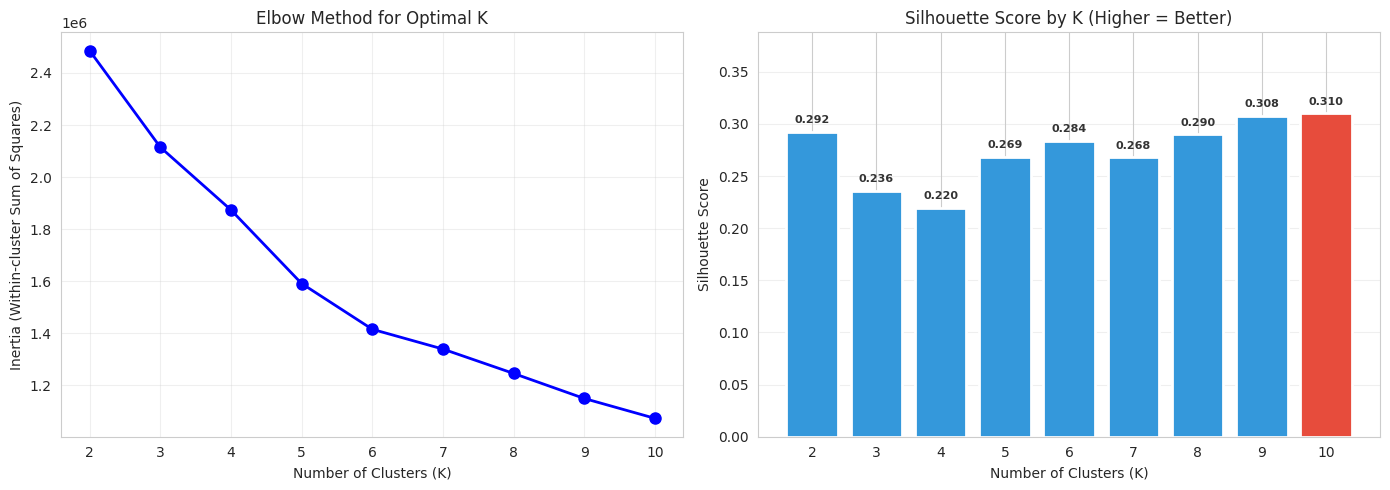


Best K by Silhouette Score: 10
Silhouette Score: 0.3103


In [12]:
# Visualize Elbow and Silhouette methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Elbow Method
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Right: Silhouette Method
colors = [COLORS['accent'] if s == max(silhouette_scores) else COLORS['secondary'] for s in silhouette_scores]
bars = axes[1].bar(list(k_range), silhouette_scores, color=colors, edgecolor='white', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K (Higher = Better)')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3, axis='y')

# Labels ABOVE with headroom
max_score = max(silhouette_scores)
axes[1].set_ylim(0, max_score * 1.25)
for bar, score in zip(bars, silhouette_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_score * 0.02, 
                 f'{score:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_minibatch_optimal_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine optimal K
best_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nBest K by Silhouette Score: {best_k_silhouette}")
print(f"Silhouette Score: {max(silhouette_scores):.4f}")

In [13]:
# Select optimal K based on analysis
optimal_k = best_k_silhouette
print(f"Selected K = {optimal_k} for clustering")
print(f"\nThis creates {optimal_k} distinct market segments.")

Selected K = 10 for clustering

This creates 10 distinct market segments.


## 6. Approach 1: Cluster Original Features, Visualize with PCA

First approach: Run K-Means on the normalized original features, then use PCA for 2D visualization.

In [14]:
# Fit final MiniBatchKMeans model
print(f"Fitting MiniBatchKMeans with K={optimal_k}...")

kmeans_original = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, 
                                   n_init=10, batch_size=1024, max_iter=300)
cluster_labels_original = kmeans_original.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_cluster['cluster_original'] = cluster_labels_original

# Check cluster sizes
print(f"\nCluster Sizes (Approach 1 - MiniBatchKMeans):")
print("=" * 40)
cluster_counts = pd.Series(cluster_labels_original).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(cluster_labels_original) * 100
    print(f"  Cluster {cluster_id}: {count:>10,} ({pct:>5.1f}%)")

Fitting MiniBatchKMeans with K=10...



Cluster Sizes (Approach 1 - MiniBatchKMeans):
  Cluster 0:     30,886 (  6.6%)
  Cluster 1:     98,734 ( 21.1%)
  Cluster 2:     38,416 (  8.2%)
  Cluster 3:     53,627 ( 11.4%)
  Cluster 4:     31,350 (  6.7%)
  Cluster 5:     73,837 ( 15.8%)
  Cluster 6:     33,466 (  7.1%)
  Cluster 7:     13,502 (  2.9%)
  Cluster 8:     42,314 (  9.0%)
  Cluster 9:     52,270 ( 11.2%)


In [15]:
# PCA for visualization (reduce to 2D)
pca_viz = PCA(n_components=2, random_state=42)
X_pca_2d = pca_viz.fit_transform(X_scaled)

print(f"PCA Explained Variance:")
print(f"  PC1: {pca_viz.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca_viz.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca_viz.explained_variance_ratio_)*100:.1f}%")

PCA Explained Variance:
  PC1: 33.8%
  PC2: 25.3%
  Total: 59.1%


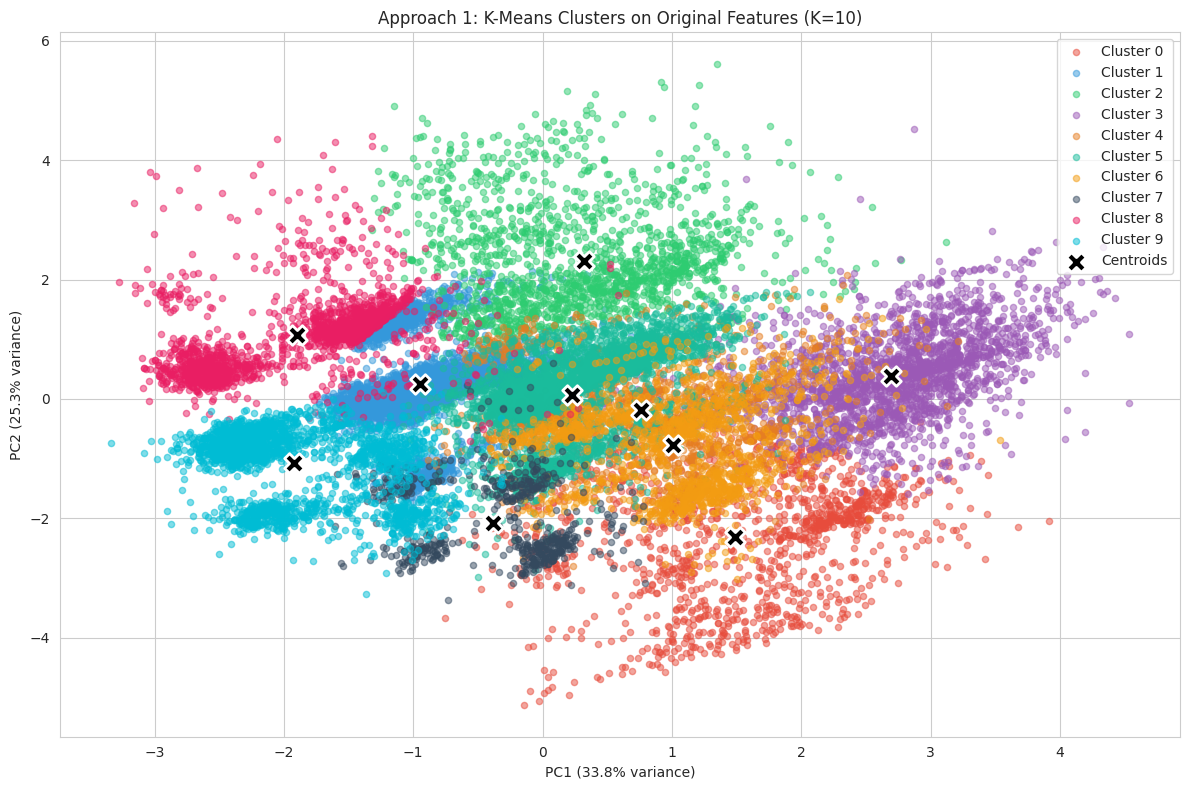


Note: Showing 20,000 sampled points for clarity.


In [16]:
# Visualize clusters with PCA
fig, ax = plt.subplots(figsize=(12, 8))

# Sample for visualization (too many points obscure patterns)
np.random.seed(42)
sample_size = min(20000, len(X_pca_2d))
sample_idx = np.random.choice(len(X_pca_2d), sample_size, replace=False)

for cluster_id in range(optimal_k):
    mask = (cluster_labels_original[sample_idx] == cluster_id)
    ax.scatter(
        X_pca_2d[sample_idx][mask, 0],
        X_pca_2d[sample_idx][mask, 1],
        c=CLUSTER_COLORS[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=20
    )

# Plot cluster centers
centers_pca = pca_viz.transform(kmeans_original.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=200, 
           edgecolors='white', linewidths=2, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Approach 1: K-Means Clusters on Original Features (K={optimal_k})')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_minibatch_clusters_pca_approach1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNote: Showing {sample_size:,} sampled points for clarity.")

## 7. Approach 2: Cluster on PCA Components

As per instructor guidance: "Do dimensionality reduction with PCA first, then cluster on principal components."

In [17]:
# PCA with enough components to capture 90% variance
pca_test = PCA(n_components=min(X_scaled.shape[1], 7), random_state=42)
pca_test.fit(X_scaled)
cumsum = np.cumsum(pca_test.explained_variance_ratio_)

n_components_90 = int(np.searchsorted(cumsum, 0.90) + 1)
print(f"Components needed for 90% variance: {n_components_90}")

pca_full = PCA(n_components=n_components_90, random_state=42)
X_pca = pca_full.fit_transform(X_scaled)

print(f"\nPCA for Clustering:")
print(f"  Original features: {X_scaled.shape[1]}")
print(f"  PCA components: {n_components_90}")
print(f"  Variance explained: {sum(pca_full.explained_variance_ratio_)*100:.1f}%")

Components needed for 90% variance: 5



PCA for Clustering:
  Original features: 7
  PCA components: 5
  Variance explained: 90.7%


In [18]:
# Cluster on PCA components (MiniBatchKMeans - fast)
print(f"\nFitting MiniBatchKMeans on PCA components (K={optimal_k})...")

kmeans_pca = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, 
                              n_init=10, batch_size=1024, max_iter=300)
cluster_labels_pca = kmeans_pca.fit_predict(X_pca)

df_cluster['cluster_pca'] = cluster_labels_pca

# Check cluster sizes
print(f"\nCluster Sizes (Approach 2 - PCA + MiniBatchKMeans):")
print("=" * 40)
cluster_counts_pca = pd.Series(cluster_labels_pca).value_counts().sort_index()
for cluster_id, count in cluster_counts_pca.items():
    pct = count / len(cluster_labels_pca) * 100
    print(f"  Cluster {cluster_id}: {count:>10,} ({pct:>5.1f}%)")


Fitting MiniBatchKMeans on PCA components (K=10)...



Cluster Sizes (Approach 2 - PCA + MiniBatchKMeans):
  Cluster 0:     22,024 (  4.7%)
  Cluster 1:     85,192 ( 18.2%)
  Cluster 2:     41,355 (  8.8%)
  Cluster 3:     54,646 ( 11.7%)
  Cluster 4:     37,458 (  8.0%)
  Cluster 5:     75,513 ( 16.1%)
  Cluster 6:     30,148 (  6.4%)
  Cluster 7:     30,460 (  6.5%)
  Cluster 8:     37,534 (  8.0%)
  Cluster 9:     54,072 ( 11.5%)


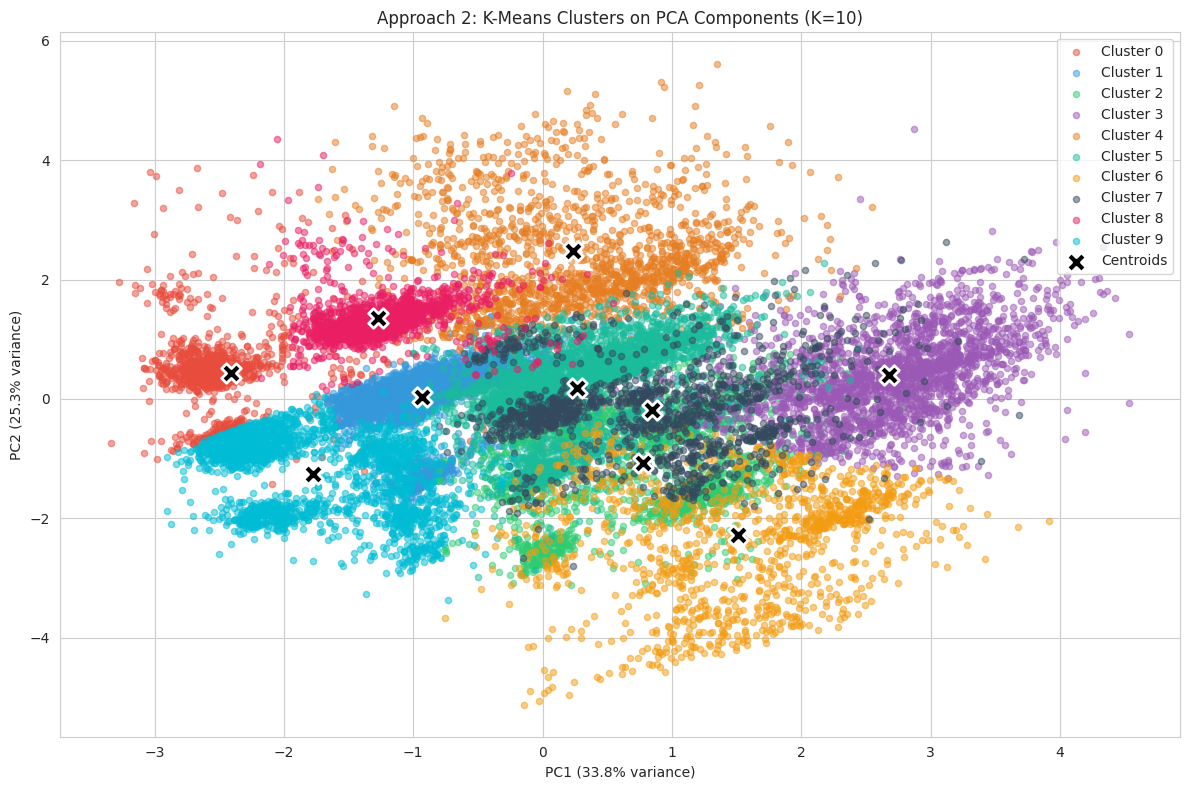

In [19]:
# Visualize Approach 2 clusters
fig, ax = plt.subplots(figsize=(12, 8))

# Use first 2 PCA components for visualization
for cluster_id in range(optimal_k):
    mask = (cluster_labels_pca[sample_idx] == cluster_id)
    ax.scatter(
        X_pca[sample_idx, 0][mask],
        X_pca[sample_idx, 1][mask],
        c=CLUSTER_COLORS[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=20
    )

# Plot centroids (only first 2 components)
ax.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], 
           c='black', marker='X', s=200, edgecolors='white', linewidths=2, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Approach 2: K-Means Clusters on PCA Components (K={optimal_k})')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_minibatch_clusters_pca_approach2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1 Compare Approach 1 vs Approach 2

In [20]:
# Compare cluster assignments between approaches
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(cluster_labels_original, cluster_labels_pca)
nmi = normalized_mutual_info_score(cluster_labels_original, cluster_labels_pca)

print("Comparison: Approach 1 (Original) vs Approach 2 (PCA)")
print("=" * 55)
print(f"  Adjusted Rand Index: {ari:.4f}")
print(f"  Normalized Mutual Information: {nmi:.4f}")
print(f"\nInterpretation:")
print(f"  ARI = 1.0 means identical clustering")
print(f"  ARI = 0.0 means random clustering")
if ari > 0.7:
    print(f"\n  Result: Both approaches produce SIMILAR clusters.")
elif ari > 0.4:
    print(f"\n  Result: Approaches have MODERATE agreement.")
else:
    print(f"\n  Result: Approaches produce DIFFERENT clusters - worth exploring both.")

Comparison: Approach 1 (Original) vs Approach 2 (PCA)
  Adjusted Rand Index: 0.8441
  Normalized Mutual Information: 0.8681

Interpretation:
  ARI = 1.0 means identical clustering
  ARI = 0.0 means random clustering

  Result: Both approaches produce SIMILAR clusters.


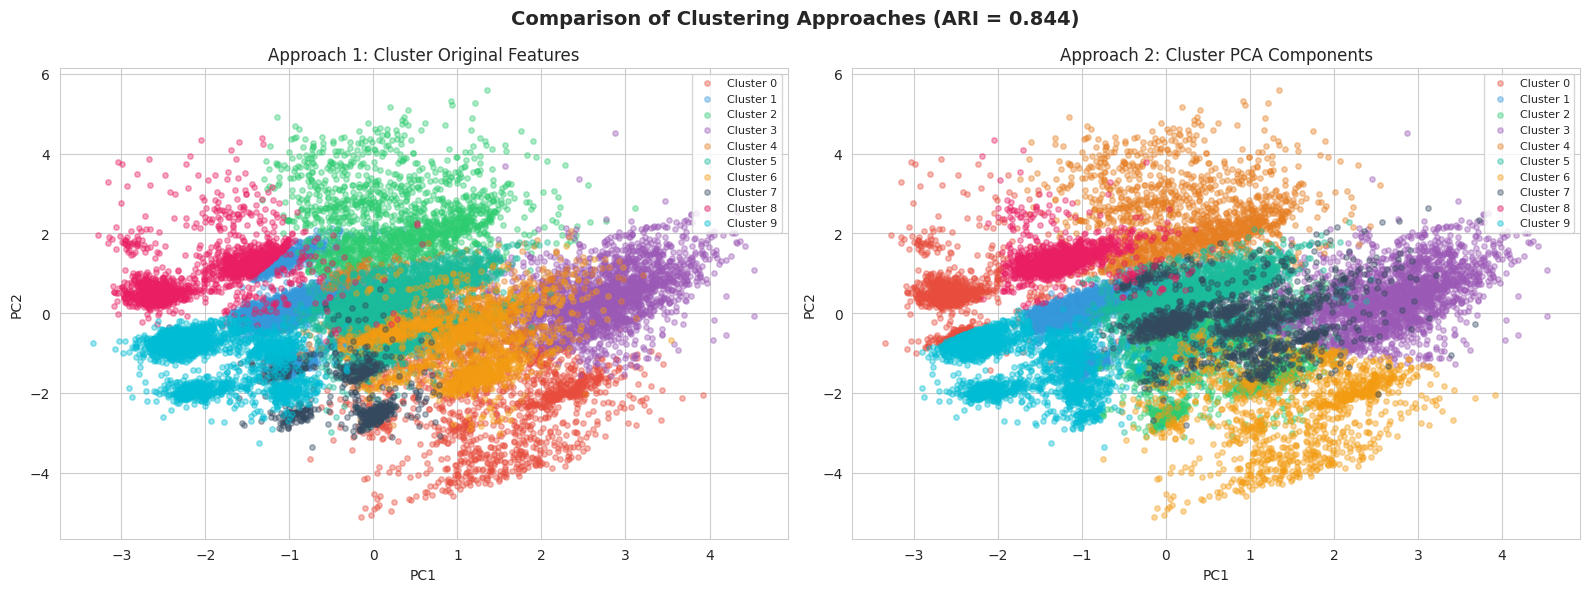

In [21]:
# Side-by-side comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Approach 1
for cluster_id in range(optimal_k):
    mask = (cluster_labels_original[sample_idx] == cluster_id)
    axes[0].scatter(
        X_pca_2d[sample_idx][mask, 0],
        X_pca_2d[sample_idx][mask, 1],
        c=CLUSTER_COLORS[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.4,
        s=15
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Approach 1: Cluster Original Features')
axes[0].legend(loc='upper right', fontsize=8)

# Approach 2
for cluster_id in range(optimal_k):
    mask = (cluster_labels_pca[sample_idx] == cluster_id)
    axes[1].scatter(
        X_pca[sample_idx, 0][mask],
        X_pca[sample_idx, 1][mask],
        c=CLUSTER_COLORS[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.4,
        s=15
    )
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Approach 2: Cluster PCA Components')
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle(f'Comparison of Clustering Approaches (ARI = {ari:.3f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_minibatch_approach_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. t-SNE Visualization

As per instructor warning: "t-SNE has stochastic behavior. Each run gives slightly different results."

We run t-SNE multiple times to identify robust patterns.

In [22]:
# t-SNE on a sample (too slow for full dataset)
tsne_sample_size = 128000
np.random.seed(42)
tsne_idx = np.random.choice(len(X_scaled), tsne_sample_size, replace=False)

X_tsne_sample = X_scaled[tsne_idx]
labels_tsne_sample = cluster_labels_original[tsne_idx]

print(f"Running t-SNE on {tsne_sample_size:,} samples...")
print("This may take 1-2 minutes per run.")

Running t-SNE on 128,000 samples...
This may take 1-2 minutes per run.


Running t-SNE with random_state=42...


Running t-SNE with random_state=123...


Running t-SNE with random_state=456...


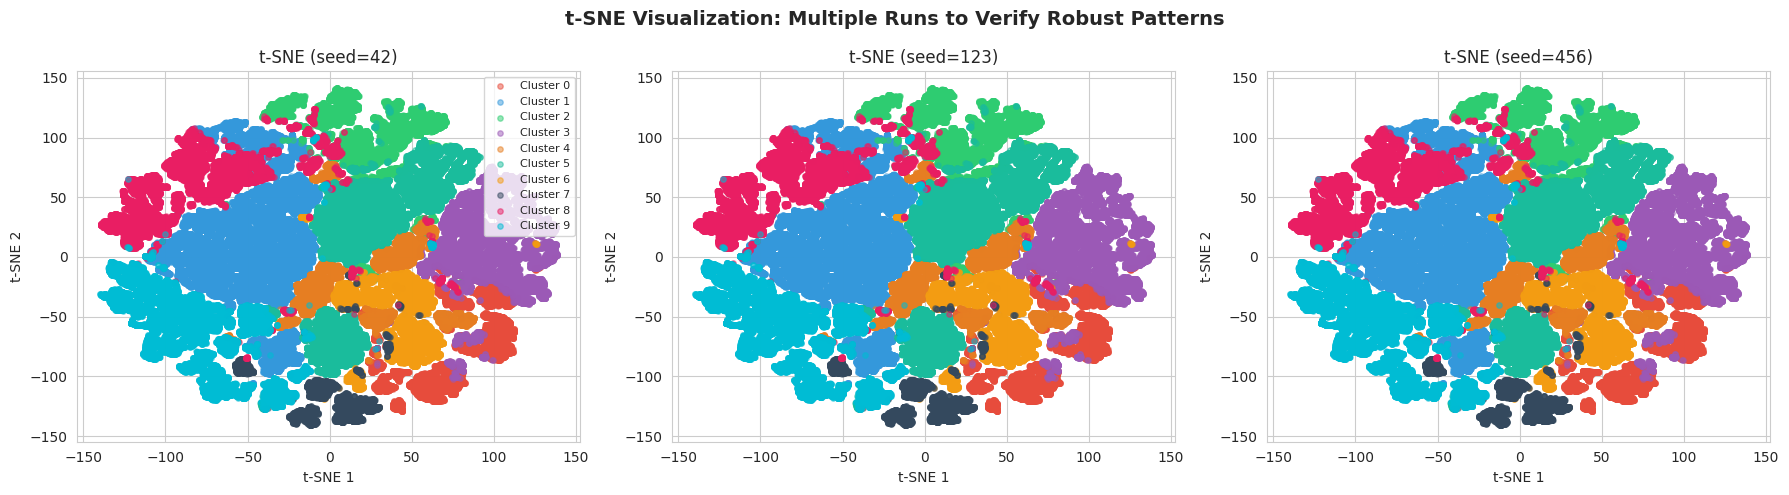


Note: t-SNE is for visualization only. Clusters are defined by K-Means.
Patterns that appear consistently across runs are robust.


In [23]:
# Run t-SNE with 3 different random states to verify robustness
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

random_states = [42, 123, 456]

for idx, rs in enumerate(random_states):
    print(f"Running t-SNE with random_state={rs}...")
    tsne = TSNE(n_jobs=-1, n_components=2, random_state=rs, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X_tsne_sample)
    
    # Plot
    for cluster_id in range(optimal_k):
        mask = (labels_tsne_sample == cluster_id)
        axes[idx].scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            c=CLUSTER_COLORS[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.5,
            s=15
        )
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].set_title(f't-SNE (seed={rs})')
    if idx == 0:
        axes[idx].legend(loc='upper right', fontsize=8)

plt.suptitle('t-SNE Visualization: Multiple Runs to Verify Robust Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_minibatch_tsne_multiple_runs.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: t-SNE is for visualization only. Clusters are defined by K-Means.")
print("Patterns that appear consistently across runs are robust.")

## 9. Cluster Interpretation

We analyze each cluster's characteristics and assign business-meaningful names.

In [24]:
# Use Approach 1 clusters for interpretation (original features)
df_cluster['cluster'] = df_cluster['cluster_original']

# Calculate cluster profiles using original (non-transformed) values
profile_features = [
    'price_per_sqm',
    'building_size',
    'rooms_numeric',
    'has_elevator_binary',
    'has_parking_binary',
    'has_warehouse_binary',
    'city_price_level'
]

cluster_profiles = df_cluster.groupby('cluster')[profile_features].mean()

print("Cluster Profiles (Mean Values)")
print("=" * 80)
print(cluster_profiles.round(2).to_string())

Cluster Profiles (Mean Values)
         price_per_sqm  building_size  rooms_numeric  has_elevator_binary  has_parking_binary  has_warehouse_binary  city_price_level
cluster                                                                                                                              
0          85407074.58          69.61           0.99                 0.10                0.03                  0.00       41468596.66
1          33473385.73         102.29           2.05                 1.00                1.00                  1.00       27739872.45
2          30340297.27         252.46           3.43                 0.01                0.96                  0.97       21861396.16
3          21559582.96         262.28           1.97                 0.00                0.00                  0.00       23095691.89
4          28898330.82          98.94           1.96                 0.55                0.90                  0.00       25366848.57
5          30258564.77         

In [25]:
# Detailed cluster statistics
print("\nDetailed Cluster Statistics")
print("=" * 80)

for cluster_id in range(optimal_k):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    n = len(cluster_data)
    pct = n / len(df_cluster) * 100
    
    print(f"\nCluster {cluster_id} ({n:,} listings, {pct:.1f}% of market)")
    print("-" * 60)
    print(f"  Price/sqm:    Median = {cluster_data['price_per_sqm'].median()/1e6:.1f}M Tomans")
    print(f"  Size:         Median = {cluster_data['building_size'].median():.0f} sqm")
    print(f"  Rooms:        Median = {cluster_data['rooms_numeric'].median():.0f}")
    print(f"  Has Elevator: {cluster_data['has_elevator_binary'].mean()*100:.0f}%")
    print(f"  Has Parking:  {cluster_data['has_parking_binary'].mean()*100:.0f}%")
    print(f"  Has Storage:  {cluster_data['has_warehouse_binary'].mean()*100:.0f}%")


Detailed Cluster Statistics

Cluster 0 (30,886 listings, 6.6% of market)
------------------------------------------------------------
  Price/sqm:    Median = 51.0M Tomans
  Size:         Median = 58 sqm
  Rooms:        Median = 1
  Has Elevator: 10%
  Has Parking:  3%
  Has Storage:  0%

Cluster 1 (98,734 listings, 21.1% of market)
------------------------------------------------------------
  Price/sqm:    Median = 31.8M Tomans
  Size:         Median = 100 sqm
  Rooms:        Median = 2
  Has Elevator: 100%
  Has Parking:  100%
  Has Storage:  100%

Cluster 2 (38,416 listings, 8.2% of market)
------------------------------------------------------------
  Price/sqm:    Median = 23.6M Tomans
  Size:         Median = 220 sqm
  Rooms:        Median = 3
  Has Elevator: 1%
  Has Parking:  96%
  Has Storage:  97%

Cluster 3 (53,627 listings, 11.4% of market)
------------------------------------------------------------
  Price/sqm:    Median = 12.3M Tomans
  Size:         Median = 202 sqm
 

  Price/sqm:    Median = 59.8M Tomans
  Size:         Median = 58 sqm
  Rooms:        Median = 1
  Has Elevator: 36%
  Has Parking:  0%
  Has Storage:  100%



Cluster 8 (42,314 listings, 9.0% of market)
------------------------------------------------------------
  Price/sqm:    Median = 80.0M Tomans
  Size:         Median = 161 sqm
  Rooms:        Median = 3
  Has Elevator: 92%
  Has Parking:  98%
  Has Storage:  97%

Cluster 9 (52,270 listings, 11.2% of market)
------------------------------------------------------------
  Price/sqm:    Median = 89.5M Tomans
  Size:         Median = 80 sqm
  Rooms:        Median = 2
  Has Elevator: 81%
  Has Parking:  100%
  Has Storage:  92%


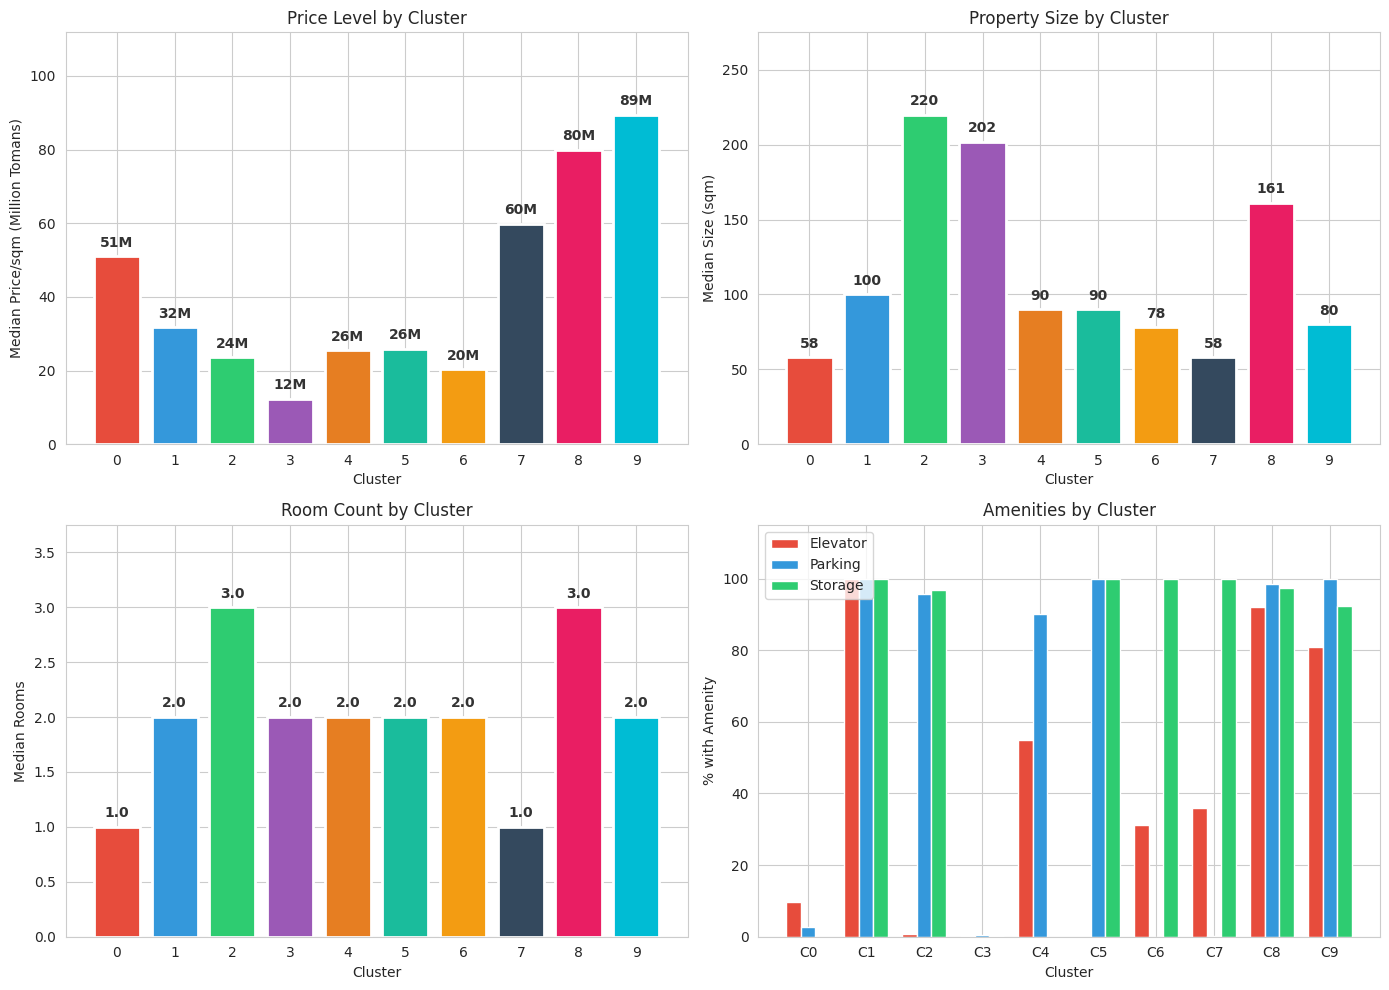

In [26]:
# Visualize cluster profiles - labels ABOVE bars
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price per sqm by cluster
cluster_price = df_cluster.groupby('cluster')['price_per_sqm'].median() / 1e6
bars = axes[0, 0].bar(range(optimal_k), cluster_price, color=CLUSTER_COLORS[:optimal_k], edgecolor='white', linewidth=2)
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Median Price/sqm (Million Tomans)')
axes[0, 0].set_title('Price Level by Cluster')
axes[0, 0].set_xticks(range(optimal_k))
max_val = cluster_price.max()
axes[0, 0].set_ylim(0, max_val * 1.25)
for i, v in enumerate(cluster_price):
    axes[0, 0].text(i, v + max_val * 0.02, f'{v:.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# 2. Building size by cluster
cluster_size = df_cluster.groupby('cluster')['building_size'].median()
bars = axes[0, 1].bar(range(optimal_k), cluster_size, color=CLUSTER_COLORS[:optimal_k], edgecolor='white', linewidth=2)
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Median Size (sqm)')
axes[0, 1].set_title('Property Size by Cluster')
axes[0, 1].set_xticks(range(optimal_k))
max_val = cluster_size.max()
axes[0, 1].set_ylim(0, max_val * 1.25)
for i, v in enumerate(cluster_size):
    axes[0, 1].text(i, v + max_val * 0.02, f'{v:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# 3. Rooms by cluster
cluster_rooms = df_cluster.groupby('cluster')['rooms_numeric'].median()
bars = axes[1, 0].bar(range(optimal_k), cluster_rooms, color=CLUSTER_COLORS[:optimal_k], edgecolor='white', linewidth=2)
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Median Rooms')
axes[1, 0].set_title('Room Count by Cluster')
axes[1, 0].set_xticks(range(optimal_k))
max_val = cluster_rooms.max()
axes[1, 0].set_ylim(0, max_val * 1.25)
for i, v in enumerate(cluster_rooms):
    axes[1, 0].text(i, v + max_val * 0.02, f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# 4. Amenities by cluster
amenity_cols = ['has_elevator_binary', 'has_parking_binary', 'has_warehouse_binary']
amenity_labels = ['Elevator', 'Parking', 'Storage']
x = np.arange(optimal_k)
width = 0.25

for i, (col, label) in enumerate(zip(amenity_cols, amenity_labels)):
    values = df_cluster.groupby('cluster')[col].mean() * 100
    axes[1, 1].bar(x + i*width, values, width, label=label, color=CLUSTER_COLORS[i], edgecolor='white', linewidth=1)

axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('% with Amenity')
axes[1, 1].set_title('Amenities by Cluster')
axes[1, 1].set_xticks(x + width)
axes[1, 1].set_xticklabels([f'C{i}' for i in range(optimal_k)])
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 115)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_minibatch_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.1 City Distribution per Cluster

In [27]:
# Top cities in each cluster
print("Top 5 Cities in Each Cluster")
print("=" * 70)

for cluster_id in range(optimal_k):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    top_cities = cluster_data['city_slug'].value_counts().head(5)
    total = len(cluster_data)
    
    print(f"\nCluster {cluster_id}:")
    for city, count in top_cities.items():
        city_name = city.replace('-', ' ').title()
        pct = count / total * 100
        print(f"  {city_name:<25} {count:>8,} ({pct:>5.1f}%)")

Top 5 Cities in Each Cluster

Cluster 0:
  Tehran                       7,676 ( 24.9%)
  Mashhad                      2,569 (  8.3%)
  Tabriz                       1,956 (  6.3%)
  Karaj                        1,644 (  5.3%)
  Isfahan                      1,296 (  4.2%)

Cluster 1:
  Mashhad                      9,594 (  9.7%)
  Karaj                        9,361 (  9.5%)
  Andisheh New Town            8,108 (  8.2%)
  Pardis City                  5,744 (  5.8%)
  Isfahan                      4,801 (  4.9%)

Cluster 2:
  Nur                          2,940 (  7.7%)
  Chamestan                    2,856 (  7.4%)
  Mashhad                      1,798 (  4.7%)
  Isfahan                      1,667 (  4.3%)
  Nowshahr                     1,650 (  4.3%)

Cluster 3:
  Mashhad                      2,179 (  4.1%)
  Isfahan                      2,079 (  3.9%)
  Shiraz                       1,912 (  3.6%)
  Karaj                        1,711 (  3.2%)
  Tabriz                       1,455 (  2.7%)

Cl


Cluster 8:
  Tehran                      18,381 ( 43.4%)
  Mashhad                      4,723 ( 11.2%)
  Shiraz                       3,329 (  7.9%)
  Karaj                        3,240 (  7.7%)
  Isfahan                      2,748 (  6.5%)

Cluster 9:
  Tehran                      50,134 ( 95.9%)
  Kish                         1,327 (  2.5%)
  Isfahan                        114 (  0.2%)
  Karaj                          108 (  0.2%)
  Shiraz                          88 (  0.2%)


In [28]:
# Tehran share in each cluster
print("\nTehran Presence in Each Cluster")
print("=" * 50)

for cluster_id in range(optimal_k):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    tehran_count = (cluster_data['city_slug'] == 'tehran').sum()
    tehran_pct = tehran_count / len(cluster_data) * 100
    print(f"Cluster {cluster_id}: {tehran_pct:.1f}% Tehran listings")


Tehran Presence in Each Cluster
Cluster 0: 24.9% Tehran listings
Cluster 1: 0.6% Tehran listings
Cluster 2: 1.7% Tehran listings
Cluster 3: 2.2% Tehran listings
Cluster 4: 1.7% Tehran listings
Cluster 5: 1.3% Tehran listings


Cluster 6: 0.1% Tehran listings
Cluster 7: 95.4% Tehran listings


Cluster 8: 43.4% Tehran listings
Cluster 9: 95.9% Tehran listings


### 9.2 Assign Business-Meaningful Names

In [29]:
# Build cluster summary for naming
cluster_summary = pd.DataFrame({
    'price_per_sqm': df_cluster.groupby('cluster')['price_per_sqm'].median(),
    'building_size': df_cluster.groupby('cluster')['building_size'].median(),
    'rooms': df_cluster.groupby('cluster')['rooms_numeric'].median(),
    'elevator_pct': df_cluster.groupby('cluster')['has_elevator_binary'].mean() * 100,
    'count': df_cluster.groupby('cluster').size()
})

# Add Tehran percentage
tehran_pcts = []
for cluster_id in range(optimal_k):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    tehran_pct = (cluster_data['city_slug'] == 'tehran').sum() / len(cluster_data) * 100
    tehran_pcts.append(tehran_pct)
cluster_summary['tehran_pct'] = tehran_pcts

print("Cluster Summary for Naming:")
print(cluster_summary.round(1).to_string())

Cluster Summary for Naming:
         price_per_sqm  building_size  rooms  elevator_pct  count  tehran_pct
cluster                                                                      
0          51000000.00          58.00   1.00          9.70  30886       24.90
1          31782945.70         100.00   2.00        100.00  98734        0.60
2          23571428.60         220.00   3.00          0.80  38416        1.70
3          12345679.00         202.00   2.00          0.20  53627        2.20
4          25555555.60          90.00   2.00         55.00  31350        1.70
5          25882352.90          90.00   2.00          0.00  73837        1.30
6          20400000.00          78.00   2.00         31.10  33466        0.10
7          59782608.70          58.00   1.00         36.00  13502       95.40
8          80000000.00         161.00   3.00         92.10  42314       43.40
9          89484969.10          80.00   2.00         80.90  52270       95.90


In [30]:
# Assign names based on characteristics
# Sort clusters by price to assign names logically
cluster_by_price = cluster_summary.sort_values('price_per_sqm', ascending=False).index.tolist()

cluster_names = {}
name_templates = [
    "Premium Properties",
    "Upper-Mid Market", 
    "Standard Family Homes",
    "Mid-Range Apartments",
    "Budget Apartments",
    "Entry-Level Units",
    "Economy Segment",
    "Value Properties",
    "Starter Homes",
    "Basic Units"
]

for rank, cluster_id in enumerate(cluster_by_price):
    row = cluster_summary.loc[cluster_id]
    
    # Customize name based on characteristics
    if row['tehran_pct'] > 60:
        location = "Tehran "
    elif row['tehran_pct'] < 20:
        location = "Provincial "
    else:
        location = ""
    
    if row['building_size'] > 120:
        size_desc = "Spacious "
    elif row['building_size'] < 70:
        size_desc = "Compact "
    else:
        size_desc = ""
    
    base_name = name_templates[min(rank, len(name_templates)-1)]
    cluster_names[cluster_id] = f"{location}{size_desc}{base_name}".strip()

print("\nCluster Names (Business Interpretation):")
print("=" * 60)
for cluster_id in range(optimal_k):
    count = len(df_cluster[df_cluster['cluster'] == cluster_id])
    pct = count / len(df_cluster) * 100
    price = cluster_summary.loc[cluster_id, 'price_per_sqm'] / 1e6
    print(f"Cluster {cluster_id}: {cluster_names[cluster_id]}")
    print(f"           ({count:,} listings, {pct:.1f}%, {price:.0f}M Tomans/sqm)")


Cluster Names (Business Interpretation):
Cluster 0: Compact Mid-Range Apartments
           (30,886 listings, 6.6%, 51M Tomans/sqm)
Cluster 1: Provincial Budget Apartments
           (98,734 listings, 21.1%, 32M Tomans/sqm)
Cluster 2: Provincial Spacious Value Properties
           (38,416 listings, 8.2%, 24M Tomans/sqm)
Cluster 3: Provincial Spacious Basic Units
           (53,627 listings, 11.4%, 12M Tomans/sqm)
Cluster 4: Provincial Economy Segment
           (31,350 listings, 6.7%, 26M Tomans/sqm)
Cluster 5: Provincial Entry-Level Units
           (73,837 listings, 15.8%, 26M Tomans/sqm)
Cluster 6: Provincial Starter Homes
           (33,466 listings, 7.1%, 20M Tomans/sqm)
Cluster 7: Tehran Compact Standard Family Homes
           (13,502 listings, 2.9%, 60M Tomans/sqm)
Cluster 8: Spacious Upper-Mid Market
           (42,314 listings, 9.0%, 80M Tomans/sqm)


Cluster 9: Tehran Premium Properties
           (52,270 listings, 11.2%, 89M Tomans/sqm)


In [31]:
# Add cluster names to dataframe
df_cluster['cluster_name'] = df_cluster['cluster'].map(cluster_names)

# Final summary table
print("\n" + "=" * 80)
print("FINAL MARKET SEGMENTATION SUMMARY")
print("=" * 80)

for cluster_id in range(optimal_k):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    n = len(cluster_data)
    pct = n / len(df_cluster) * 100
    
    print(f"\n{cluster_names[cluster_id]} (Cluster {cluster_id})")
    print(f"  Count: {n:,} ({pct:.1f}%)")
    print(f"  Price/sqm: {cluster_data['price_per_sqm'].median()/1e6:.1f}M Tomans")
    print(f"  Size: {cluster_data['building_size'].median():.0f} sqm")
    print(f"  Elevator: {cluster_data['has_elevator_binary'].mean()*100:.0f}%")


FINAL MARKET SEGMENTATION SUMMARY

Compact Mid-Range Apartments (Cluster 0)
  Count: 30,886 (6.6%)
  Price/sqm: 51.0M Tomans
  Size: 58 sqm
  Elevator: 10%

Provincial Budget Apartments (Cluster 1)
  Count: 98,734 (21.1%)
  Price/sqm: 31.8M Tomans
  Size: 100 sqm
  Elevator: 100%

Provincial Spacious Value Properties (Cluster 2)
  Count: 38,416 (8.2%)
  Price/sqm: 23.6M Tomans
  Size: 220 sqm
  Elevator: 1%

Provincial Spacious Basic Units (Cluster 3)
  Count: 53,627 (11.4%)
  Price/sqm: 12.3M Tomans
  Size: 202 sqm
  Elevator: 0%

Provincial Economy Segment (Cluster 4)
  Count: 31,350 (6.7%)
  Price/sqm: 25.6M Tomans
  Size: 90 sqm
  Elevator: 55%

Provincial Entry-Level Units (Cluster 5)
  Count: 73,837 (15.8%)
  Price/sqm: 25.9M Tomans
  Size: 90 sqm
  Elevator: 0%

Provincial Starter Homes (Cluster 6)
  Count: 33,466 (7.1%)
  Price/sqm: 20.4M Tomans
  Size: 78 sqm
  Elevator: 31%

Tehran Compact Standard Family Homes (Cluster 7)
  Count: 13,502 (2.9%)
  Price/sqm: 59.8M Tomans
  S


Spacious Upper-Mid Market (Cluster 8)
  Count: 42,314 (9.0%)


  Price/sqm: 80.0M Tomans
  Size: 161 sqm
  Elevator: 92%

Tehran Premium Properties (Cluster 9)
  Count: 52,270 (11.2%)
  Price/sqm: 89.5M Tomans
  Size: 80 sqm
  Elevator: 81%


## 10. Cluster Size Distribution

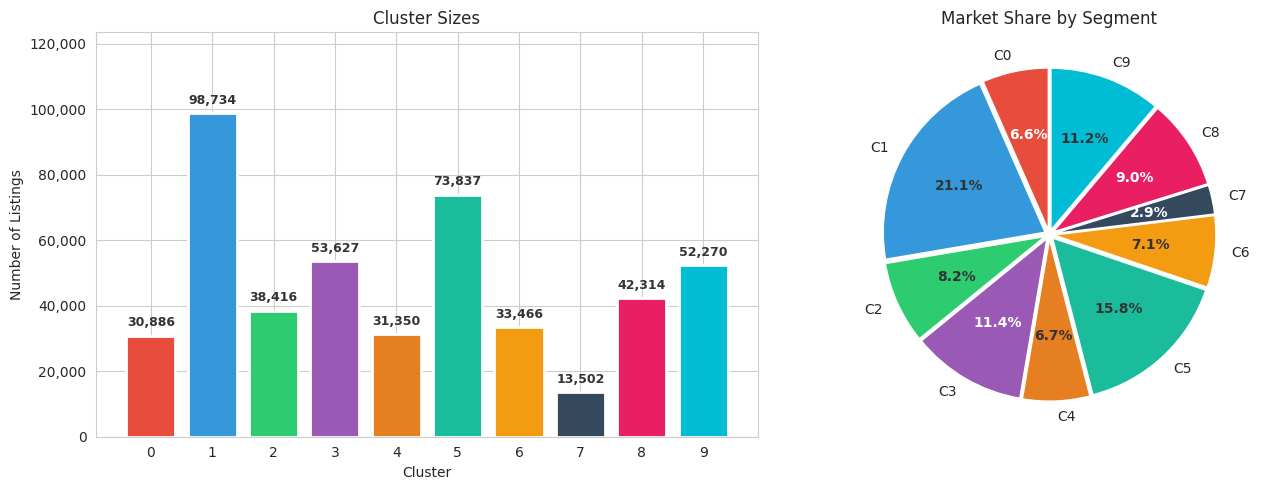

In [32]:
# Visualize cluster distribution - labels ABOVE bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes
cluster_sizes = df_cluster['cluster'].value_counts().sort_index()

# Left: Bar chart with labels ABOVE
bars = axes[0].bar(range(optimal_k), cluster_sizes, color=CLUSTER_COLORS[:optimal_k], edgecolor='white', linewidth=2)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Cluster Sizes')
axes[0].set_xticks(range(optimal_k))
max_val = cluster_sizes.max()
axes[0].set_ylim(0, max_val * 1.25)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

for i, v in enumerate(cluster_sizes):
    axes[0].text(i, v + max_val * 0.02, f'{v:,}', ha='center', va='bottom', fontsize=9, 
                 fontweight='bold', color='#333333')

# Right: Pie chart with adaptive text colors for visibility
labels = [f"C{i}" for i in range(optimal_k)]
wedges, texts, autotexts = axes[1].pie(cluster_sizes, labels=labels, autopct='%1.1f%%', 
                                        colors=CLUSTER_COLORS[:optimal_k], startangle=90,
                                        explode=[0.03]*optimal_k)

# Function to determine if color is dark (needs white text)
def is_dark_color(color):
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(color)
    # Calculate luminance
    luminance = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return luminance < 0.5

for i, autotext in enumerate(autotexts):
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    # Use white text for dark backgrounds, dark text for light backgrounds
    if is_dark_color(CLUSTER_COLORS[i]):
        autotext.set_color('white')
    else:
        autotext.set_color('#333333')

axes[1].set_title('Market Share by Segment')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_minibatch_cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Key Findings Summary

In [33]:
print("=" * 70)
print("PHASE 4: KEY FINDINGS SUMMARY")
print("=" * 70)

print(f"""
CLUSTERING RESULTS
------------------
  Total listings clustered: {len(df_cluster):,}
  Number of clusters: {optimal_k}
  Best silhouette score: {max(silhouette_scores):.4f}

METHODOLOGY
-----------
  Features: 7 (price, size, rooms, amenities, city)
  City encoding: Target encoding (by median price)
  Normalization: StandardScaler
  Log transform: price_per_sqm, building_size, city_price_level
  Algorithm: K-Means (standard)

APPROACH COMPARISON
-------------------
  Approach 1 (Original Features): Primary results
  Approach 2 (PCA Components): {X_pca.shape[1]} components (90% variance)
  Adjusted Rand Index: {ari:.4f}
  Conclusion: {'Similar' if ari > 0.7 else 'Moderate agreement' if ari > 0.4 else 'Different'} cluster structures

MARKET SEGMENTS IDENTIFIED
--------------------------""")

for cluster_id in range(optimal_k):
    count = len(df_cluster[df_cluster['cluster'] == cluster_id])
    pct = count / len(df_cluster) * 100
    price = df_cluster[df_cluster['cluster'] == cluster_id]['price_per_sqm'].median() / 1e6
    print(f"  {cluster_id}. {cluster_names[cluster_id]}")
    print(f"     {count:,} listings ({pct:.1f}%), Median: {price:.0f}M Tomans/sqm")

print("\n" + "=" * 70)

PHASE 4: KEY FINDINGS SUMMARY

CLUSTERING RESULTS
------------------
  Total listings clustered: 468,402
  Number of clusters: 10
  Best silhouette score: 0.3103

METHODOLOGY
-----------
  Features: 7 (price, size, rooms, amenities, city)
  City encoding: Target encoding (by median price)
  Normalization: StandardScaler
  Log transform: price_per_sqm, building_size, city_price_level
  Algorithm: K-Means (standard)

APPROACH COMPARISON
-------------------
  Approach 1 (Original Features): Primary results
  Approach 2 (PCA Components): 5 components (90% variance)
  Adjusted Rand Index: 0.8441
  Conclusion: Similar cluster structures

MARKET SEGMENTS IDENTIFIED
--------------------------
  0. Compact Mid-Range Apartments
     30,886 listings (6.6%), Median: 51M Tomans/sqm
  1. Provincial Budget Apartments
     98,734 listings (21.1%), Median: 32M Tomans/sqm
  2. Provincial Spacious Value Properties
     38,416 listings (8.2%), Median: 24M Tomans/sqm
  3. Provincial Spacious Basic Units
  

  4. Provincial Economy Segment
     31,350 listings (6.7%), Median: 26M Tomans/sqm
  5. Provincial Entry-Level Units
     73,837 listings (15.8%), Median: 26M Tomans/sqm
  6. Provincial Starter Homes
     33,466 listings (7.1%), Median: 20M Tomans/sqm
  7. Tehran Compact Standard Family Homes
     13,502 listings (2.9%), Median: 60M Tomans/sqm
  8. Spacious Upper-Mid Market
     42,314 listings (9.0%), Median: 80M Tomans/sqm


  9. Tehran Premium Properties
     52,270 listings (11.2%), Median: 89M Tomans/sqm



## 12. Export Results

In [34]:
# Save cluster assignments
export_cols = ['city_slug', 'price_per_sqm', 'building_size', 'rooms_numeric', 
               'has_elevator_binary', 'has_parking_binary', 
               'has_warehouse_binary', 'cluster', 'cluster_name']

df_cluster[export_cols].to_csv(DATA_PROCESSED / 'clustering_assignments.csv', index=False)
print(f"Saved: clustering_assignments.csv ({len(df_cluster):,} rows)")

# Save cluster profiles
cluster_profiles_export = df_cluster.groupby('cluster').agg({
    'price_per_sqm': ['median', 'mean', 'std'],
    'building_size': ['median', 'mean'],
    'rooms_numeric': ['median', 'mean'],
    'has_elevator_binary': 'mean',
    'has_parking_binary': 'mean',
    'has_warehouse_binary': 'mean',
    'city_slug': 'count'
}).round(2)

cluster_profiles_export.columns = ['_'.join(col).strip() for col in cluster_profiles_export.columns]
cluster_profiles_export['cluster_name'] = cluster_profiles_export.index.map(cluster_names)
cluster_profiles_export.to_csv(DATA_PROCESSED / 'cluster_profiles.csv')
print(f"Saved: cluster_profiles.csv")

# Save summary
summary_data = {
    'cluster': list(range(optimal_k)),
    'name': [cluster_names[i] for i in range(optimal_k)],
    'count': [len(df_cluster[df_cluster['cluster'] == i]) for i in range(optimal_k)],
    'median_price_per_sqm': [df_cluster[df_cluster['cluster'] == i]['price_per_sqm'].median() for i in range(optimal_k)],
    'median_size': [df_cluster[df_cluster['cluster'] == i]['building_size'].median() for i in range(optimal_k)]
}
pd.DataFrame(summary_data).to_csv(DATA_PROCESSED / 'clustering_summary.csv', index=False)
print(f"Saved: clustering_summary.csv")

print(f"\nAll figures saved to: {FIGURES_PATH}")

Saved: clustering_assignments.csv (468,402 rows)
Saved: cluster_profiles.csv


Saved: clustering_summary.csv

All figures saved to: /root/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/notebooks/outputs/figures


---

## 13. Conclusion

### Phase 4 Deliverables

| Output | Description |
|--------|-------------|
| Optimal K selection | Elbow and Silhouette analysis |
| Approach 1 clusters | K-Means on original features |
| Approach 2 clusters | K-Means on PCA components |
| Approach comparison | ARI and visual comparison |
| t-SNE visualization | Multiple runs for robustness |
| Cluster profiles | Detailed statistics per cluster |
| Business names | Interpretable segment labels |
| City distribution | Geographic patterns per cluster |

### Files Created

- `clustering_assignments.csv` - Full data with cluster labels
- `cluster_profiles.csv` - Statistics per cluster
- `clustering_summary.csv` - Summary table
- Figures: `04_*.png` in figures directory

### Key Insights

The real estate market naturally segments into distinct categories based on price, size, amenities, and location. These segments provide actionable intelligence:

- **For Buyers**: Identify which market segment matches your budget and needs
- **For Sellers**: Understand your competition within your segment
- **For Investors**: Spot opportunities in underserved segments

---

**Phase 4 Complete**

Proceed to **Phase 5: Price Prediction**